# **MLflow**

In [1]:
# Import 
import mlflow
import mlflow.sklearn
import os
import json
import matplotlib.pyplot as plt

In [2]:
print("MLflow version:", mlflow.__version__)

MLflow version: 3.15.1


In [3]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: sqlite:///mlflow.db


# **Classification MLflow**

In [20]:
# Classification experiment
import mlflow
import mlflow.sklearn
import os

# Set experiment name
mlflow.set_experiment("EMI_Eligibility_Classification")

print("MLflow Classification experiment created/selected successfully.")

MLflow Classification experiment created/selected successfully.


In [21]:
import joblib

classification_model = joblib.load("best_classification_model.pkl")

print("Classification model loaded successfully!")
print("Model type:", type(classification_model))

Classification model loaded successfully!
Model type: <class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier'>


In [22]:
print(classification_model)

HistGradientBoostingClassifier(random_state=42)


In [23]:
import pandas as pd

df = pd.read_csv("feature_engineered_dataset.csv")

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Dataset shape: (388233, 30)
Columns:
['age', 'gender', 'marital_status', 'education', 'monthly_salary', 'employment_type', 'years_of_employment', 'company_type', 'house_type', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'existing_loans', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario', 'requested_amount', 'requested_tenure', 'max_monthly_emi', 'total_monthly_expenses', 'disposable_income', 'expense_to_income_ratio', 'emi_eligibility']


In [24]:
import joblib

target_encoder = joblib.load("target_encoder.pkl")

print("Target encoder loaded successfully!")
print(target_encoder)

Target encoder loaded successfully!
LabelEncoder()


In [25]:
# Prepare X and y
target_column = "emi_eligibility"

X = df.drop(columns=[target_column])
y = df[target_column]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target values:", y.unique())

X shape: (388233, 29)
y shape: (388233,)
Target values: [2 0 1]


In [26]:
# Train and Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (310586, 29)
X_test: (77647, 29)
y_train: (310586,)
y_test: (77647,)


In [27]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("feature_engineered_dataset.csv")

# Target
target_column = "emi_eligibility"

X = df.drop(columns=[target_column])
y = df[target_column]

# Same split used in 05_classification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Load final classification winner
classification_model = joblib.load("best_classification_model.pkl")

print("Dataset:", df.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Model:", classification_model)

Dataset: (388233, 30)
X_train: (310586, 29)
X_test: (77647, 29)
Model: HistGradientBoostingClassifier(random_state=42)


In [28]:
# Load the winner
import joblib

classification_model = joblib.load("best_classification_model.pkl")

print("Classification model loaded!")
print(classification_model)

Classification model loaded!
HistGradientBoostingClassifier(random_state=42)


In [29]:
try:
    y_pred = classification_model.predict(X_test)

    print("Prediction successful!")
    print("Predictions shape:", y_pred.shape)

except Exception as e:
    print("Prediction error:", e)

Prediction successful!
Predictions shape: (77647,)


In [30]:
# Calculate classification metrix
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Classification Metrics")
print("----------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Classification Metrics
----------------------
Accuracy : 0.9880999909848417
Precision: 0.9877084364498344
Recall   : 0.9880999909848417
F1 Score : 0.987761053696827

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     14276
           1       0.91      0.81      0.85      3353
           2       0.99      1.00      1.00     60018

    accuracy                           0.99     77647
   macro avg       0.96      0.93      0.95     77647
weighted avg       0.99      0.99      0.99     77647



In [31]:
#  mlflow run
mlflow.set_experiment("EMI_Eligibility_Classification")

with mlflow.start_run(run_name="HistGradientBoosting_Classifier") as run:

    mlflow.log_param("model_type", "HistGradientBoostingClassifier")
    mlflow.log_param("random_state", 42)
    mlflow.log_param("test_size", 0.20)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision_weighted", precision)
    mlflow.log_metric("recall_weighted", recall)
    mlflow.log_metric("f1_weighted", f1)

    mlflow.sklearn.log_model(
        classification_model,
        name="classification_model"
    )

    print("Classification run logged to SQLite!")
    print("Run ID:", run.info.run_id)

Classification run logged to SQLite!
Run ID: 1a0602ab6b3748a2a667a175352bc592


In [32]:
# Verify the run
print("Tracking URI:", mlflow.get_tracking_uri())

runs = mlflow.search_runs(
    experiment_names=["EMI_Eligibility_Classification"]
)

print(runs[[
    "run_id",
    "status",
    "metrics.accuracy",
    "metrics.f1_weighted"
]])

Tracking URI: sqlite:///mlflow.db
                             run_id    status  metrics.accuracy  \
0  1a0602ab6b3748a2a667a175352bc592  FINISHED            0.9881   
1  c2b9daa929094e58944e8f2e16d46572  FINISHED            0.9881   

   metrics.f1_weighted  
0             0.987761  
1             0.987761  


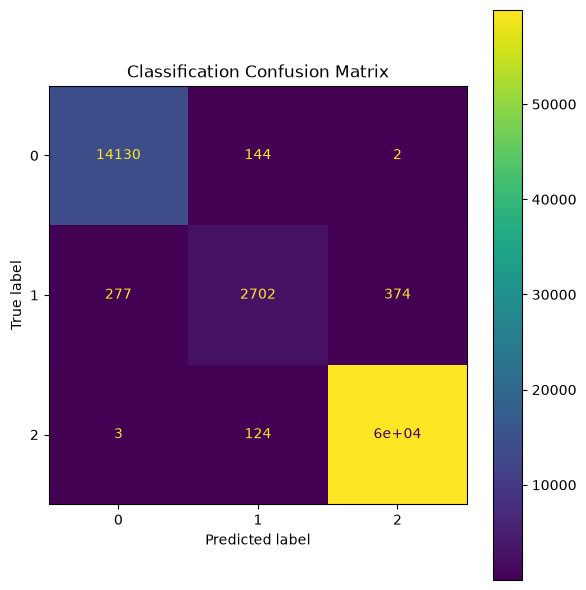

Confusion matrix saved: classification_confusion_matrix.png


In [33]:
# Confusion metrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax)

plt.title("Classification Confusion Matrix")
plt.tight_layout()

# Save the figure
confusion_matrix_path = "classification_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=150)
plt.show()

print("Confusion matrix saved:", confusion_matrix_path)

In [34]:
# Log it to mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("EMI_Eligibility_Classification")

<Experiment: artifact_location='file:c:/Users/avani/Documents/EMIPredict-AI/notebooks/mlruns/2', creation_time=1787233872092, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1787233872092, lifecycle_stage='active', name='EMI_Eligibility_Classification', tags={}, trace_location=None, workspace='default'>

In [35]:
# MLflow run
with mlflow.start_run(run_name="HistGradientBoosting_Classifier_Final") as run:

    # Parameters
    mlflow.log_param("model_type", "HistGradientBoostingClassifier")
    mlflow.log_param("random_state", 42)
    mlflow.log_param("test_size", 0.20)

    # Metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision_weighted", precision)
    mlflow.log_metric("recall_weighted", recall)
    mlflow.log_metric("f1_weighted", f1)

    # Confusion matrix artifact
    mlflow.log_artifact(confusion_matrix_path, artifact_path="evaluation")

    # Model
    mlflow.sklearn.log_model(
        classification_model,
        name="classification_model"
    )

    print("Final classification MLflow run completed!")
    print("Run ID:", run.info.run_id)

Final classification MLflow run completed!
Run ID: a45d7d38576641a298c7bcffc57356ca


In [36]:
# Verify the Artifacts
runs = mlflow.search_runs(
    experiment_names=["EMI_Eligibility_Classification"]
)

print(runs[[
    "run_id",
    "status",
    "metrics.accuracy",
    "metrics.f1_weighted"
]])

                             run_id    status  metrics.accuracy  \
0  a45d7d38576641a298c7bcffc57356ca  FINISHED            0.9881   
1  1a0602ab6b3748a2a667a175352bc592  FINISHED            0.9881   
2  c2b9daa929094e58944e8f2e16d46572  FINISHED            0.9881   

   metrics.f1_weighted  
0             0.987761  
1             0.987761  
2             0.987761  


# **Register the MLflow model**

In [39]:
# registering the classification model
import mlflow

classification_run_id = "a45d7d38576641a298c7bcffc57356ca"

model_uri = f"runs:/{classification_run_id}/classification_model"

registered_model = mlflow.register_model(
    model_uri=model_uri,
    name="Classification_Best_Model"
)

print("Classification model registered successfully!")
print("Model name:", registered_model.name)
print("Version:", registered_model.version)

Successfully registered model 'Classification_Best_Model'.
2026/08/22 12:32:21 WARNING mlflow.tracking._model_registry.fluent: Run with id a45d7d38576641a298c7bcffc57356ca has no artifacts at artifact path 'classification_model', registering model based on models:/m-220a4245a76441d9ac470fb6f0ddb321 instead
Created version '1' of model 'Classification_Best_Model'.


Classification model registered successfully!
Model name: Classification_Best_Model
Version: 1


# **Regression MLflow**

In [4]:
import joblib

regression_model = joblib.load("best_regression_model.pkl")
xgb_regression_model = joblib.load("best_regression_model_xgb.pkl")

print("Best regression model:")
print(regression_model)

print("\nXGBoost regression model:")
print(xgb_regression_model)

Best regression model:
RandomForestRegressor(n_jobs=-1, random_state=42)

XGBoost regression model:
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)


In [5]:
import joblib

regression_model = joblib.load("best_regression_model_xgb.pkl")

print("Final regression model loaded!")
print(regression_model)

Final regression model loaded!
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)


In [6]:
# regression train split
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split

# Load feature-engineered dataset
df = pd.read_csv("feature_engineered_dataset.csv")

# Regression target
target_column = "requested_amount"

X = df.drop(columns=[target_column])
y = df[target_column]

# Same split used in 06_regression
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Load official regression winner
regression_model = joblib.load("best_regression_model_xgb.pkl")

print("Dataset shape:", df.shape)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
print("\nModel:", regression_model)

Dataset shape: (388233, 30)
X_train: (310586, 29)
X_test : (77647, 29)
y_train: (310586,)
y_test : (77647,)

Model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)


In [7]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTarget shape:")
print(y_train.shape, y_test.shape)

print("\nTarget dtype:")
print(y_train.dtype)

X_train shape: (310586, 29)
X_test shape: (77647, 29)

Target shape:
(310586,) (77647,)

Target dtype:
float64


In [8]:
from xgboost import XGBRegressor

regression_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

regression_model.fit(X_train, y_train)

print("Regression model trained successfully!")
print("Model expects:", regression_model.n_features_in_)

Regression model trained successfully!
Model expects: 29


In [9]:
# Test the prediction
try:
    y_pred_reg = regression_model.predict(X_test)

    print("Prediction successful!")
    print("Predictions shape:", y_pred_reg.shape)

except Exception as e:
    print("Prediction error:", e)

Prediction successful!
Predictions shape: (77647,)


In [10]:
print("First 10 predictions:")
print(y_pred_reg[:10])

print("\nFirst 10 actual values:")
print(y_test.values[:10])

First 10 predictions:
[411620.5   146020.4   754691.3   627081.94  339131.22  112118.81
 163113.08  645209.2   111848.766 109486.75 ]

First 10 actual values:
[122000. 110000. 444000. 401000. 283000.  47000. 119000. 389000.  83000.
 147000.]


In [11]:
# Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_reg))
r2 = r2_score(y_test, y_pred_reg)

print("Regression Model Evaluation")
print("---------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Regression Model Evaluation
---------------------------
MAE : 134674.42980742437
RMSE: 201306.3778980453
R²  : 0.6577401956485843


In [12]:
# Regression MLflow run
import mlflow
import mlflow.xgboost

mlflow.set_experiment("Regression_Model")

with mlflow.start_run() as run:

    # Log model parameters
    mlflow.log_param("model", "XGBRegressor")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("n_features", X_train.shape[1])

    # Log evaluation metrics
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2", r2)

    # Log the trained model
    mlflow.xgboost.log_model(
        regression_model,
        artifact_path="regression_model"
    )

    print("MLflow run completed successfully!")
    print("Run ID:", run.info.run_id)

2026/08/22 12:19:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow run completed successfully!
Run ID: ccb0747b818540e0b5ff83bcdb686ddc


In [13]:
# Load the MLflow model
import mlflow

run_id = "5b43280f64f14e7f990e511482e149e1"

model_uri = f"runs:/{run_id}/regression_model"

loaded_regression_model = mlflow.xgboost.load_model(model_uri)

print("Model loaded successfully!")
print("Model type:", type(loaded_regression_model))
print("Features expected:", loaded_regression_model.n_features_in_)

Model loaded successfully!
Model type: <class 'xgboost.sklearn.XGBRegressor'>
Features expected: 29


In [14]:
# Test the loaded model
y_pred_mlflow = loaded_regression_model.predict(X_test)

print("MLflow model prediction successful!")
print("Predictions shape:", y_pred_mlflow.shape)
print("First 10 predictions:")
print(y_pred_mlflow[:10])

MLflow model prediction successful!
Predictions shape: (77647,)
First 10 predictions:
[411620.5   146020.4   754691.3   627081.94  339131.22  112118.81
 163113.08  645209.2   111848.766 109486.75 ]


In [15]:
# Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_mlflow = mean_absolute_error(y_test, y_pred_mlflow)
rmse_mlflow = np.sqrt(mean_squared_error(y_test, y_pred_mlflow))
r2_mlflow = r2_score(y_test, y_pred_mlflow)

print("MLflow Model Evaluation")
print("-----------------------")
print("MAE :", mae_mlflow)
print("RMSE:", rmse_mlflow)
print("R²  :", r2_mlflow)

MLflow Model Evaluation
-----------------------
MAE : 134674.42980742437
RMSE: 201306.3778980453
R²  : 0.6577401956485843


In [16]:
print("\nOriginal Model vs MLflow Model")
print("--------------------------------")
print("MAE  :", mae, " | ", mae_mlflow)
print("RMSE :", rmse, " | ", rmse_mlflow)
print("R²   :", r2, " | ", r2_mlflow)


Original Model vs MLflow Model
--------------------------------
MAE  : 134674.42980742437  |  134674.42980742437
RMSE : 201306.3778980453  |  201306.3778980453
R²   : 0.6577401956485843  |  0.6577401956485843


In [17]:
# Verify the model run
import mlflow

run_id = "5b43280f64f14e7f990e511482e149e1"

run = mlflow.get_run(run_id)

print("===== MLflow Run Verification =====")

print("\nRun ID:")
print(run.info.run_id)

print("\nExperiment ID:")
print(run.info.experiment_id)

print("\nStatus:")
print(run.info.status)

print("\nParameters:")
for key, value in run.data.params.items():
    print(f"{key}: {value}")

print("\nMetrics:")
for key, value in run.data.metrics.items():
    print(f"{key}: {value}")

===== MLflow Run Verification =====

Run ID:
5b43280f64f14e7f990e511482e149e1

Experiment ID:
3

Status:
FINISHED

Parameters:
model: XGBRegressor
n_estimators: 200
learning_rate: 0.05
max_depth: 6
random_state: 42
n_features: 29

Metrics:
MAE: 134674.42980742437
RMSE: 201306.3778980453
R2: 0.6577401956485843


# **Register the MLflow models**

In [18]:
# Register the regression model
import mlflow

run_id = "5b43280f64f14e7f990e511482e149e1"

model_uri = f"runs:/{run_id}/regression_model"

registered_model = mlflow.register_model(
    model_uri=model_uri,
    name="Regression_Best_Model"
)

print("Regression model registered successfully!")
print("Model name:", registered_model.name)
print("Version:", registered_model.version)

Successfully registered model 'Regression_Best_Model'.
2026/08/22 12:22:16 WARNING mlflow.tracking._model_registry.fluent: Run with id 5b43280f64f14e7f990e511482e149e1 has no artifacts at artifact path 'regression_model', registering model based on models:/m-878ae983e6b048318ae5b47d33ab4520 instead
Created version '1' of model 'Regression_Best_Model'.


Regression model registered successfully!
Model name: Regression_Best_Model
Version: 1


In [44]:
# registering the classification model
import mlflow

classification_run_id = "a45d7d38576641a298c7bcffc57356ca"

model_uri = f"runs:/{classification_run_id}/classification_model"

registered_model = mlflow.register_model(
    model_uri=model_uri,
    name="Classification_Best_Model"
)

print("Classification model registered successfully!")
print("Model name:", registered_model.name)
print("Version:", registered_model.version)

Registered model 'Classification_Best_Model' already exists. Creating a new version of this model...
2026/08/22 12:48:43 WARNING mlflow.tracking._model_registry.fluent: Run with id a45d7d38576641a298c7bcffc57356ca has no artifacts at artifact path 'classification_model', registering model based on models:/m-220a4245a76441d9ac470fb6f0ddb321 instead
Created version '2' of model 'Classification_Best_Model'.


Classification model registered successfully!
Model name: Classification_Best_Model
Version: 2


In [45]:
import mlflow

print("Tracking URI:")
print(mlflow.get_tracking_uri())

Tracking URI:
sqlite:///mlflow.db


In [46]:
import os

print("Current working directory:")
print(os.getcwd())

Current working directory:
c:\Users\avani\Documents\EMIPredict-AI\notebooks


In [47]:
experiments = mlflow.search_experiments()

print("Experiments found:")
for exp in experiments:
    print(
        "Name:", exp.name,
        "| ID:", exp.experiment_id,
        "| Location:", exp.artifact_location
    )

Experiments found:
Name: Regression_Model | ID: 3 | Location: file:c:/Users/avani/Documents/EMIPredict-AI/notebooks/mlruns/3
Name: EMI_Eligibility_Classification | ID: 2 | Location: file:c:/Users/avani/Documents/EMIPredict-AI/notebooks/mlruns/2
Name: EMI_Prediction_Project | ID: 1 | Location: file:c:/Users/avani/Documents/EMIPredict-AI/notebooks/mlruns/1
Name: Default | ID: 0 | Location: file:c:/Users/avani/Documents/EMIPredict-AI/notebooks/mlruns/0


In [48]:
print(mlflow.get_tracking_uri())
print(os.getcwd())

for exp in mlflow.search_experiments():
    print(exp.name, exp.experiment_id, exp.artifact_location)

sqlite:///mlflow.db
c:\Users\avani\Documents\EMIPredict-AI\notebooks
Regression_Model 3 file:c:/Users/avani/Documents/EMIPredict-AI/notebooks/mlruns/3
EMI_Eligibility_Classification 2 file:c:/Users/avani/Documents/EMIPredict-AI/notebooks/mlruns/2
EMI_Prediction_Project 1 file:c:/Users/avani/Documents/EMIPredict-AI/notebooks/mlruns/1
Default 0 file:c:/Users/avani/Documents/EMIPredict-AI/notebooks/mlruns/0


# **Check on MLflow**

1. cd "C:\Users\avani\Documents\EMIPredict-AI\notebooks"
2. mlflow ui --backend-store-uri "sqlite:///mlflow.db" --host 127.0.0.1 --port 5000